In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
from IPython.display import display
from statsmodels.stats.inter_rater import fleiss_kappa

warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.notebook_repr_html', True)

In [2]:
# === METRICS & LABELS ===
metrics = [
    'relevance',
    'clarity',
    'answerability',
    'challenging',
    'value',
    'language',
    'bloom_rating',
]
metric_labels = {
    'relevance': 'Relevance',
    'clarity': 'Clarity',
    'answerability': 'Answerability',
    'challenging': 'Challenging',
    'value': 'Value',
    'language': 'Language',
    'bloom_rating': 'Bloom Rating',
}

In [3]:
base_path = Path("../60_analyses/csv/qualitative/exp2/students")

BASE_PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
hint_base_path = os.path.join(BASE_PROJECT_PATH, "20_experiments/60_analyses/csv/qualitative/exp2/hints")
output_base_path = os.path.join(BASE_PROJECT_PATH, "40_evaluation/exp2/qualitative")
output_tables_path = os.path.join(output_base_path, "tables")
output_plots_path = os.path.join(output_base_path, "plots")

for path in [output_tables_path, output_plots_path]:
    os.makedirs(path, exist_ok=True)

tables = {}
plots = {}

overlap_config = {
    "student_1": {
        "exp2a": range(1, 17),   # Questions 1-16
        "exp2b": range(1, 5),    # Questions 1-4
        "exp2c": []
    },
    "student_2": {
        "exp2a": range(11, 17),  # Questions 11-16  
        "exp2b": range(1, 9),    # Questions 1-8
        "exp2c": range(1, 7)     # Questions 1-6
    },
    "student_3": {
        "exp2a": [],
        "exp2b": range(5, 9),    # Questions 5-8
        "exp2c": range(1, 17)    # Questions 1-16
    }
}

In [4]:
def load_student_data(student_id):
    student_path = base_path / f"student_{student_id}"
    data = {}
    
    for exp in ["exp2a", "exp2b", "exp2c"]:
        csv_path = student_path / f"{exp}.csv"
        if csv_path.exists():
            # Check overlap configuration first - skip if no questions assigned
            questions = overlap_config[f"student_{student_id}"][exp]
            if not questions:  # Skip if empty range
                print(f"Skipping {exp} for student_{student_id} - no questions assigned in overlap_config")
                continue
            
            # Try multiple encodings to handle German characters
            df = None
            for encoding in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
                try:
                    df = pd.read_csv(csv_path, encoding=encoding)
                    break
                except UnicodeDecodeError:
                    continue
            
            if df is None:
                print(f"Error: Could not read {csv_path} with any encoding")
                continue
                
            df = df.drop('comments', axis=1)
            
            # Apply overlap configuration filter
            df['sample_id'] = df['sample_id'].astype(str)
            df['question_num'] = df['sample_id'].str.extract('(\d+)').astype(int).iloc[:, 0]
            
            # Filter to only include questions in overlap_config
            df_filtered = df[df['question_num'].isin(questions)]
            
            if len(df_filtered) == 0:
                print(f"Warning: No matching questions found for {exp} student_{student_id} with overlap_config")
                continue
            
            df_filtered['student'] = student_id
            df_filtered['experiment'] = exp
            data[exp] = df_filtered
            
            print(f"Loaded {exp} for student_{student_id}: {len(df_filtered)} questions (filtered by overlap_config: {list(questions)})")
    
    return data

def load_hint_data():
    hint_data = {}
    for exp in ["exp2a", "exp2b", "exp2c"]:
        hint_path = os.path.join(hint_base_path, f"{exp}_hints.csv")
        if os.path.exists(hint_path):
            # Try multiple encodings for hint files too
            hint_df = None
            for encoding in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
                try:
                    hint_df = pd.read_csv(hint_path, encoding=encoding)
                    break
                except UnicodeDecodeError:
                    continue
            
            if hint_df is None:
                print(f"Error: Could not read {hint_path} with any encoding")
                continue
            
            # Handle different file structures
            if 'question_id' in hint_df.columns:
                # exp2a format: has explicit question_id column
                hint_df['sample_id'] = hint_df['question_id'].astype(str)
            elif 'bloom_original' in hint_df.columns:
                # exp2b and exp2c format: bloom_original contains the question_id
                hint_df['sample_id'] = hint_df['bloom_original'].astype(str)
            else:
                print(f"Warning: No question_id or bloom_original column found in {exp}_hints.csv")
                continue
                
            print(f"Loaded {exp}_hints.csv: {len(hint_df)} rows")
            hint_data[exp] = hint_df
    return hint_data

# Load all student data with strict overlap configuration
print("Loading student data with overlap configuration:")
for student, config in overlap_config.items():
    print(f"  {student}:")
    for exp, questions in config.items():
        if questions:
            print(f"    {exp}: Questions {list(questions)}")
        else:
            print(f"    {exp}: No questions assigned")

all_data = {}
for i in range(1, 4):
    # print(f"\n--- Loading student_{i} ---")
    all_data[f"student_{i}"] = load_student_data(i)

hint_data = load_hint_data()

Loading student data with overlap configuration:
  student_1:
    exp2a: Questions [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    exp2b: Questions [1, 2, 3, 4]
    exp2c: No questions assigned
  student_2:
    exp2a: Questions [11, 12, 13, 14, 15, 16]
    exp2b: Questions [1, 2, 3, 4, 5, 6, 7, 8]
    exp2c: Questions [1, 2, 3, 4, 5, 6]
  student_3:
    exp2a: No questions assigned
    exp2b: Questions [5, 6, 7, 8]
    exp2c: Questions [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Loaded exp2a for student_1: 16 questions (filtered by overlap_config: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16])
Loaded exp2b for student_1: 4 questions (filtered by overlap_config: [1, 2, 3, 4])
Skipping exp2c for student_1 - no questions assigned in overlap_config
Loaded exp2a for student_2: 6 questions (filtered by overlap_config: [11, 12, 13, 14, 15, 16])
Loaded exp2b for student_2: 8 questions (filtered by overlap_config: [1, 2, 3, 4, 5, 6, 7, 8])
Loaded exp2c for stud

In [5]:
def combine_data():
    combined = []
    
    print("\n--- Combining data with overlap configuration ---")
    for student, experiments in all_data.items():
        print(f"\n{student}:")
        for exp, df in experiments.items():
            if not df.empty:
                # Add hint data (llm, question_type) 
                if exp in hint_data:
                    hint_df = hint_data[exp]
                    
                    # Determine which columns to merge based on what's available
                    merge_columns = ['sample_id', 'llm']
                    if 'question_type' in hint_df.columns:
                        merge_columns.append('question_type')
                    
                    # Merge on sample_id (both should be strings now)
                    df_merged = df.merge(hint_df[merge_columns], on='sample_id', how='left')
                    
                    # Verify overlap configuration is respected
                    questions_range = overlap_config[student][exp]
                    actual_questions = sorted(df_merged['question_num'].unique())
                    expected_questions = list(questions_range)
                    
                    print(f"  {exp}: {len(df_merged)} evaluations")
                    print(f"    Expected questions (overlap_config): {expected_questions}")
                    print(f"    Actual questions loaded: {actual_questions}")
                    
                    # Verify all questions are within expected range
                    unexpected = set(actual_questions) - set(expected_questions)
                    if unexpected:
                        print(f"    WARNING: Unexpected questions found: {list(unexpected)}")
                    
                    combined.append(df_merged)
                else:
                    print(f"  {exp}: {len(df)} evaluations (no hint data available)")
                    combined.append(df)
    
    if combined:
        return pd.concat(combined, ignore_index=True)
    return pd.DataFrame()

df_combined = combine_data()
print(f"\n=== FINAL SUMMARY ===")
print(f"Total evaluations: {len(df_combined)}")

if len(df_combined) > 0:
    print(f"\nBreakdown by student:")
    for student_id in sorted(df_combined['student'].unique()):
        student_data = df_combined[df_combined['student'] == student_id]
        print(f"  Student {student_id}: {len(student_data)} evaluations")
        for exp in ["exp2a", "exp2b", "exp2c"]:
            exp_data = student_data[student_data['experiment'] == exp]
            if len(exp_data) > 0:
                questions = sorted(exp_data['question_num'].unique())
                print(f"    {exp}: {len(exp_data)} evaluations, Questions: {questions}")
    
    # print(f"\nBreakdown by experiment:")
    # for exp in ["exp2a", "exp2b", "exp2c"]:
    #     exp_data = df_combined[df_combined['experiment'] == exp]
    #     print(f"  {exp}: {len(exp_data)} evaluations")
    #     if len(exp_data) > 0:
    #         students = sorted(exp_data['student'].unique())
    #         questions = sorted(exp_data['question_num'].unique())
    #         print(f"    Students: {students}")
    #         print(f"    Questions: {questions}")

    # # Check LLM distribution
    # if 'llm' in df_combined.columns:
    #     print(f"\nBreakdown by LLM:")
    #     llm_counts = df_combined.groupby('llm').size()
    #     for llm, count in llm_counts.items():
    #         print(f"  {llm}: {count} evaluations")
        
    # if 'question_type' in df_combined.columns:
    #     print(f"\nBreakdown by question type:")
    #     qtype_counts = df_combined.groupby('question_type').size()
    #     for qtype, count in qtype_counts.items():
    #         print(f"  {qtype}: {count} evaluations")
    
    # Verify overlap configuration compliance
    # print(f"\n=== OVERLAP CONFIGURATION VERIFICATION ===")
    # for student_id in range(1, 4):
    #     student_key = f"student_{student_id}"
    #     if student_key in overlap_config:
    #         config = overlap_config[student_key]
    #         student_data = df_combined[df_combined['student'] == student_id]
            
    #         print(f"\nStudent {student_id}:")
    #         for exp in ["exp2a", "exp2b", "exp2c"]:
    #             expected_questions = list(config[exp]) if config[exp] else []
    #             exp_data = student_data[student_data['experiment'] == exp]
    #             actual_questions = sorted(exp_data['question_num'].unique()) if len(exp_data) > 0 else []
                
    #             status = "Y" if set(actual_questions) == set(expected_questions) else "N"
    #             print(f"  {exp}: {status}")
    #             print(f"    Expected: {expected_questions}")
    #             print(f"    Actual:   {actual_questions}")
                
    #             if set(actual_questions) != set(expected_questions):
    #                 missing = set(expected_questions) - set(actual_questions)
    #                 extra = set(actual_questions) - set(expected_questions)
    #                 if missing:
    #                     print(f"    Missing:  {list(missing)}")
    #                 if extra:
    #                     print(f"    Extra:    {list(extra)}")
    
else:
    print("No data loaded. Check if CSV files exist and contain data.")


--- Combining data with overlap configuration ---

student_1:
  exp2a: 26 evaluations
    Expected questions (overlap_config): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    Actual questions loaded: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
  exp2b: 6 evaluations
    Expected questions (overlap_config): [1, 2, 3, 4]
    Actual questions loaded: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

student_2:
  exp2a: 6 evaluations
    Expected questions (overlap_config): [11, 12, 13, 14, 15, 16]
    Actual questions loaded: [np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
  exp2b: 12 evaluations
    Expected questions (overlap_config): [1, 2, 3, 4, 5, 6, 7, 8]
    Actual questions loaded: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6),

In [6]:
def get_config_triplets():
    '''
    Liefert alle (experiment, question_num, student) Tripel, die laut overlap_config bewertet werden sollen (alle zugeordneten Fragen pro Student).
    '''
    config_triplets = []
    for student_id in range(1, 4):
        student_key = f"student_{student_id}"
        for exp in ["exp2a", "exp2b", "exp2c"]:
            questions = overlap_config[student_key][exp]
            for q_num in questions:
                config_triplets.append( (exp, q_num, student_id) )
    return config_triplets

def get_config_df(df):
    '''
    Filtert den DataFrame exakt auf die Tripel (experiment, question_num, student) aus overlap_config.
    '''
    config_triplets = get_config_triplets()
    mask = pd.Series([False]*len(df))
    for exp, q_num, student_id in config_triplets:
        mask = mask | ( (df['experiment'] == exp) & (df['question_num'] == q_num) & (df['student'] == student_id) )
    return df[mask].copy()

# --- Korrigierte Logik: Alle laut overlap_config zugeordneten Ratings ---
print("\n=== RATINGS GEMÄSS OVERLAP_CONFIG ===")
config_triplets = get_config_triplets()
print(f"Es gibt {len(config_triplets)} relevante Bewertungen laut overlap_config.")
if len(config_triplets) > 0:
    print("Beispiel-Triplets (experiment, question_num, student):", config_triplets[:10])
else:
    print("Keine Triplets gefunden.")

# Filtere den kombinierten DataFrame exakt auf diese Tripel
df_config_ratings = get_config_df(df_combined)
print(f"Gefundene Bewertungen im DataFrame: {len(df_config_ratings)}")
print(f"Verfügbare Experimente: {sorted(df_config_ratings['experiment'].unique())}")
print(f"Verfügbare Fragen: {sorted(df_config_ratings['question_num'].unique())}")
print(f"Verfügbare Studenten: {sorted(df_config_ratings['student'].unique())}")

# Für spätere Analysen:
overlap_info = {
    'config_triplets': config_triplets,
    'n_config_triplets': len(config_triplets),
    'df_config_ratings': df_config_ratings,
    'overlap_questions': sorted(df_config_ratings['sample_id'].unique())
}


=== RATINGS GEMÄSS OVERLAP_CONFIG ===
Es gibt 60 relevante Bewertungen laut overlap_config.
Beispiel-Triplets (experiment, question_num, student): [('exp2a', 1, 1), ('exp2a', 2, 1), ('exp2a', 3, 1), ('exp2a', 4, 1), ('exp2a', 5, 1), ('exp2a', 6, 1), ('exp2a', 7, 1), ('exp2a', 8, 1), ('exp2a', 9, 1), ('exp2a', 10, 1)]
Gefundene Bewertungen im DataFrame: 100
Verfügbare Experimente: ['exp2a', 'exp2b', 'exp2c']
Verfügbare Fragen: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
Verfügbare Studenten: [np.int64(1), np.int64(2), np.int64(3)]


# Experiment 2: Descriptive Statistics

Analysis of prompt engineering approaches for question generation.

In [7]:
def convert_bloom_rating_simple(value, experiment):
    """
    Converts bloom_rating to a numeric score based on experiment type.
    For exp2a: uses Bloom level mapping. Handles values like '(4;5;6)' by taking the max.
    For exp2b/exp2c: uses correctness mapping.
    """
    if experiment == 'exp2a':
        bloom_map = {
            'Creating': 10,
            'Evaluating': 8.5,
            'Analyzing': 7,
            'Applying': 4.5,
            'Understanding': 3,
            'Remembering': 1.5,
            6: 10,
            5: 8.5,
            4: 7,
            3: 4.5,
            2: 3,
            1: 1.5
        }
        # Handle values like '(4;5;6)'
        if isinstance(value, str):
            import re
            nums = re.findall(r'\d+', value)
            if nums:
                max_num = max(int(n) for n in nums)
                return bloom_map.get(max_num, np.nan)
            value = value.strip()
            return bloom_map.get(value, np.nan)
        return bloom_map.get(value, np.nan)
    elif experiment in ['exp2b', 'exp2c']:
        if isinstance(value, str):
            value = value.strip().lower()
            if value == 'correct':
                return 10
            elif value == 'off by one':
                return 5
            else:
                return 0
        return 0
    else:
        return np.nan


EXPERIMENT 2 - DESCRIPTIVE STATISTICS (GENAU DIE RATINGS AUS OVERLAP_CONFIG)
WARNUNG: 58 Duplikate in df_config_ratings gefunden! (werden entfernt)


,experiment,question_num,student,sample_id
0,exp2a,1,1,1
1,exp2a,1,1,1
2,exp2a,2,1,2
3,exp2a,2,1,2
4,exp2a,3,1,3
5,exp2a,3,1,3
6,exp2a,4,1,4
7,exp2a,4,1,4
8,exp2a,4,1,4
9,exp2a,4,1,4


Anzahl Bewertungen in df_config_ratings nach Duplikat-Entfernung: 60 (sollte 60 sein)
Converting metrics to numeric (overlap_config ratings)...

Overall Statistics (GENAU DIE RATINGS AUS OVERLAP_CONFIG, all metrics on 0-10 scale):


,relevance,clarity,answerability,challenging,value,language,bloom_rating
count,60.0,60.00,60.0,60.00,60.00,60.00,60.00
mean,-99.0,9.07,-99.0,7.07,8.87,8.65,1.33
std,0.0,1.40,0.0,2.56,1.35,1.85,2.20
min,-99.0,4.00,-99.0,0.00,4.00,3.00,0.00
25%,-99.0,8.00,-99.0,6.00,8.00,7.00,0.00
50%,-99.0,10.00,-99.0,8.00,10.00,10.00,0.00
75%,-99.0,10.00,-99.0,8.00,10.00,10.00,3.00
max,-99.0,10.00,-99.0,10.00,10.00,10.00,8.50



Statistics by Experiment (GENAU DIE RATINGS AUS OVERLAP_CONFIG):


relevance            clarity             answerability             \
                mean  std count    mean   std count          mean  std count   
experiment                                                                     
exp2a          -99.0  0.0    22    9.18  1.01    22         -99.0  0.0    22   
exp2b          -99.0  0.0    16    8.62  1.89    16         -99.0  0.0    16   
exp2c          -99.0  0.0    22    9.27  1.32    22         -99.0  0.0    22   

           challenging             value             language              \
                  mean   std count  mean   std count     mean   std count   
experiment                                                                  
exp2a             7.45  2.48    22  8.55  1.41    22     8.59  1.82    22   
exp2b             8.38  1.50    16  9.00  1.46    16     8.62  2.06    16   
exp2c             5.73  2.71    22  9.09  1.19    22     8.73  1.80    22   

           bloom_rating              
                   mean   std count  
experiment                           
exp2a              3.64  2.19    22  
exp2b              0.00  0.00    16  
exp2c              0.00  0.00    22


Fragen pro Experiment (nur overlap_config):
  exp2a: Questions [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)] (22 Bewertungen)
  exp2b: Questions [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)] (16 Bewertungen)
  exp2c: Questions [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)] (22 Bewertungen)

=== VISUALIZATION: PERFORMANCE BY EXPERIMENT (NUR RATINGS AUS OVERLAP_CONFIG) ===


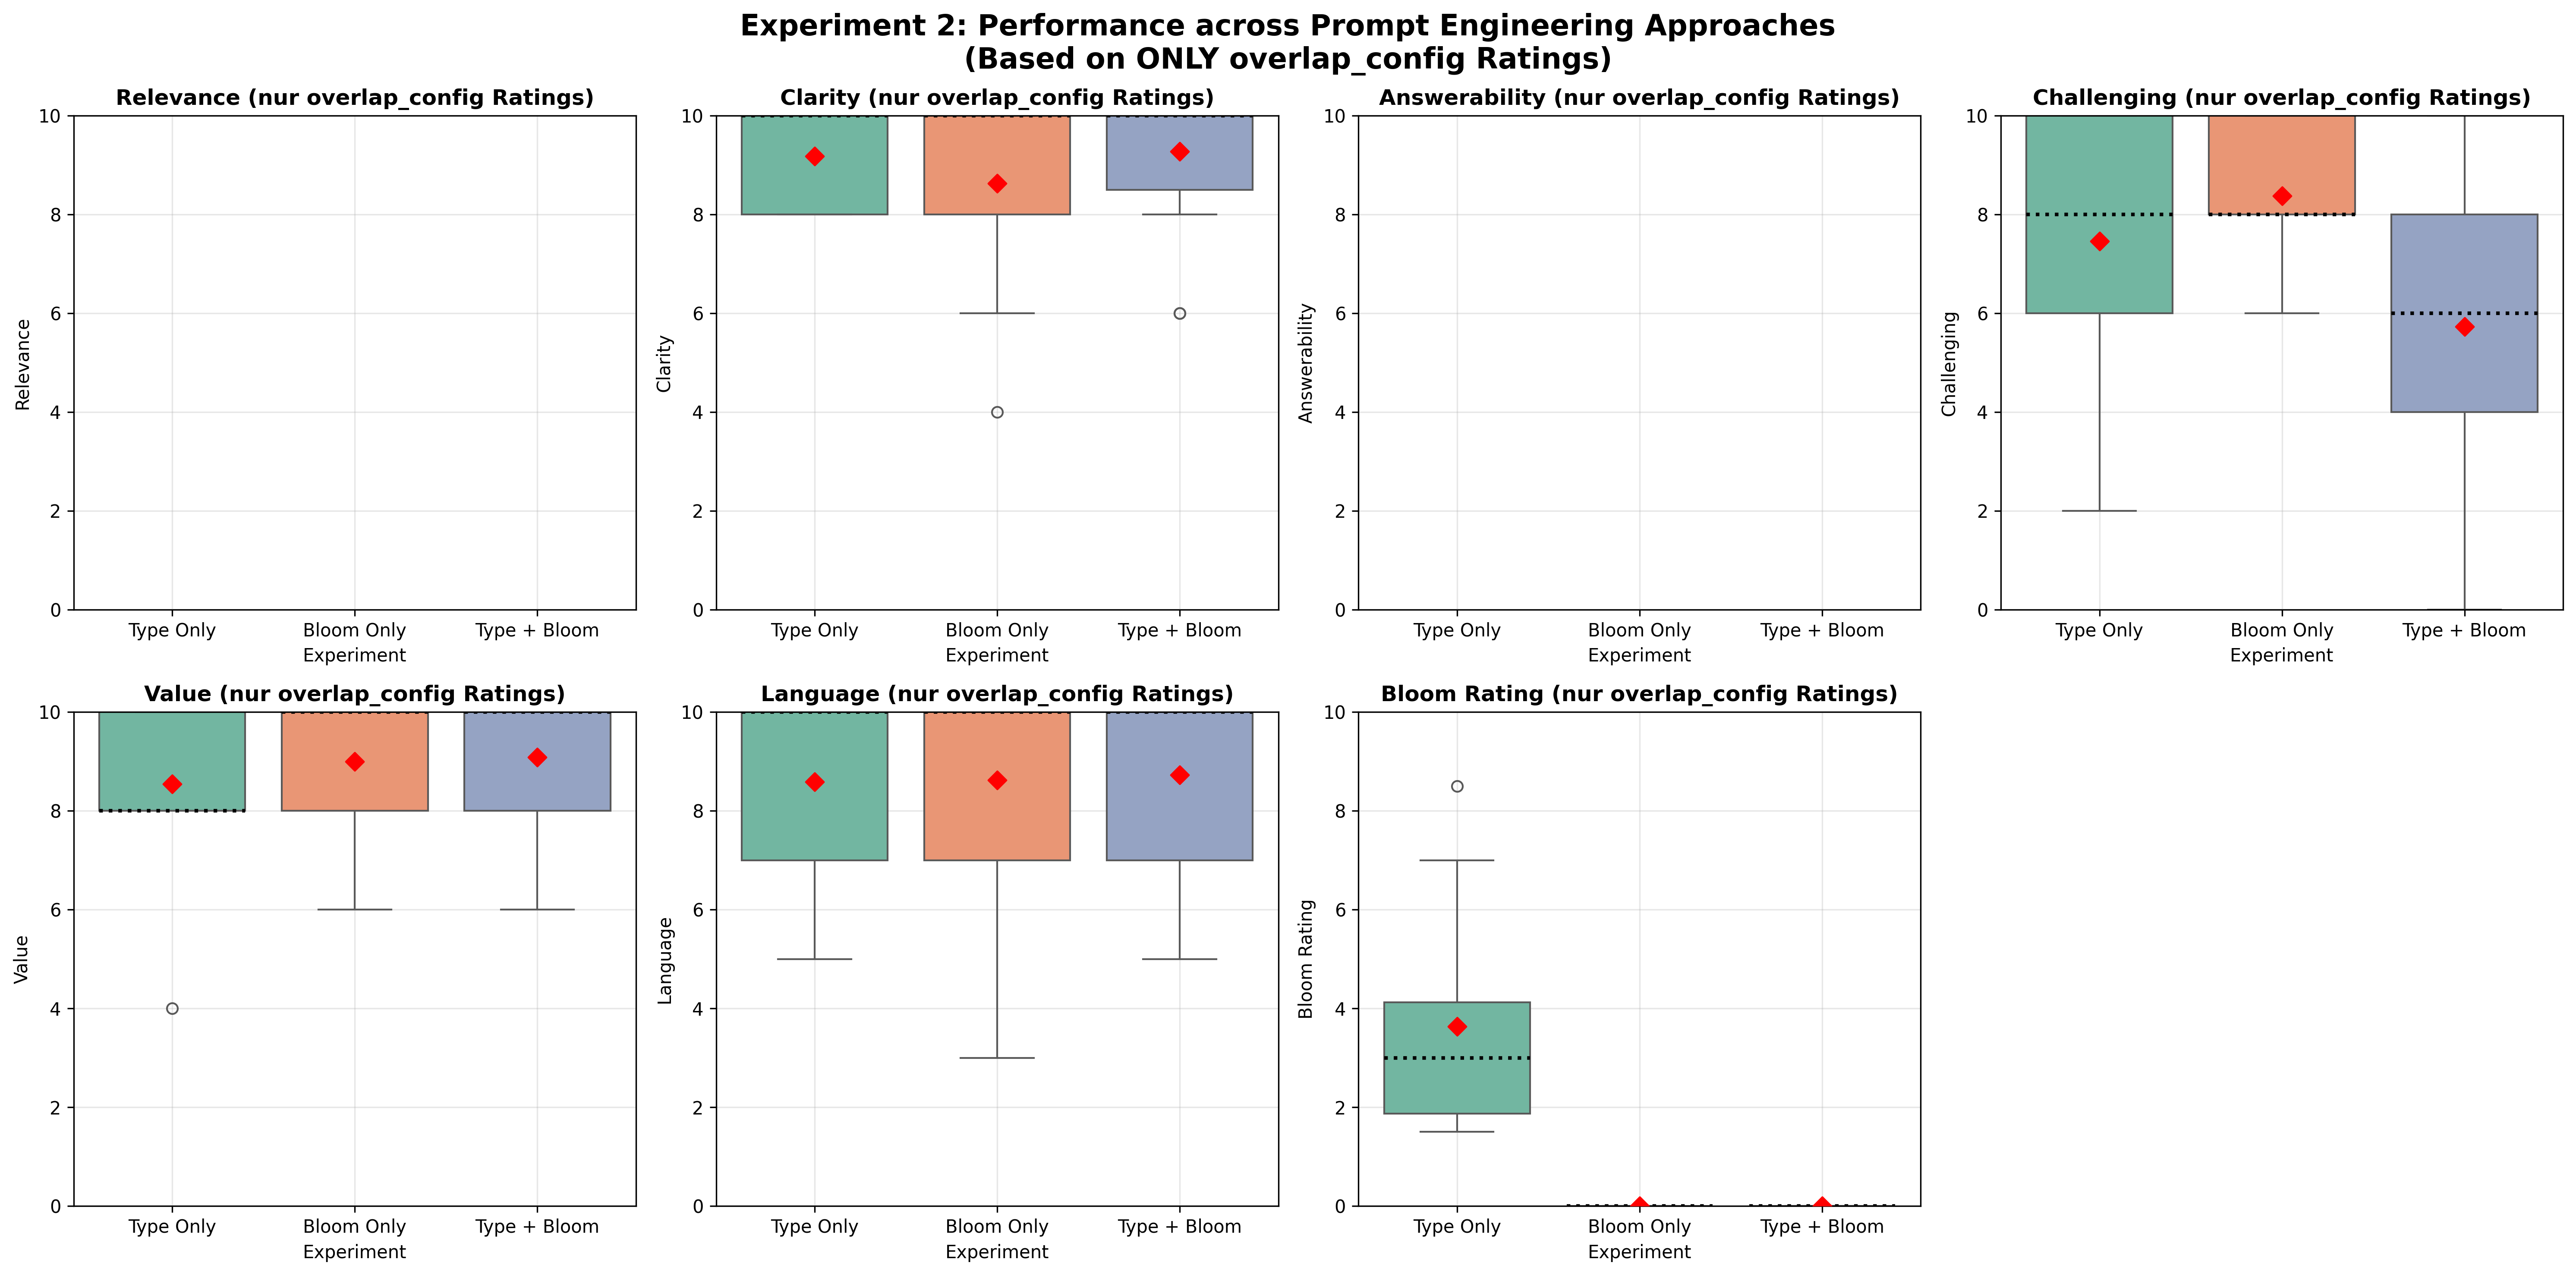

Visualization complete.
Note: Diese Visualisierung enthält exakt die 60 Bewertungen aus overlap_config.


In [8]:
# --- DESKRIPTIVE STATISTIKEN & PLOTS: NUR RATINGS AUS OVERLAP_CONFIG (GENAU DIE 60 TRIPLETS) ---

print("EXPERIMENT 2 - DESCRIPTIVE STATISTICS (GENAU DIE RATINGS AUS OVERLAP_CONFIG)")
print("="*70)

# Diagnose Duplikate
triplet_cols = ['experiment', 'question_num', 'student']
duplicates = df_config_ratings[df_config_ratings.duplicated(subset=triplet_cols, keep=False)]
if len(duplicates) > 0:
    print(f"WARNUNG: {len(duplicates)} Duplikate in df_config_ratings gefunden! (werden entfernt)")
    display(duplicates[[*triplet_cols, 'sample_id']])
    df_config_ratings = df_config_ratings.drop_duplicates(subset=triplet_cols, keep='first').reset_index(drop=True)
else:
    print("Keine Duplikate in df_config_ratings gefunden.")

print(f"Anzahl Bewertungen in df_config_ratings nach Duplikat-Entfernung: {len(df_config_ratings)} (sollte 60 sein)")
assert len(df_config_ratings) == len(set([(row['experiment'], row['question_num'], row['student']) for _, row in df_config_ratings.iterrows()])), "df_config_ratings enthält weiterhin Duplikate!"

# Create consistent numeric dataset for all ratings as per overlap_config
df_numeric_config = df_config_ratings.copy()

print("Converting metrics to numeric (overlap_config ratings)...")
for metric in metrics:
    if metric == 'bloom_rating':
        # Apply simplified bloom rating conversion
        df_numeric_config[metric] = df_config_ratings.apply(
            lambda row: convert_bloom_rating_simple(row[metric], row['experiment']), 
            axis=1
        )
    else:
        # Standard numeric conversion for other metrics
        df_numeric_config[metric] = pd.to_numeric(df_config_ratings[metric], errors='coerce')

# Basic statistics - ONLY ratings from overlap_config
if len(df_numeric_config) > 0:
    print("\nOverall Statistics (GENAU DIE RATINGS AUS OVERLAP_CONFIG, all metrics on 0-10 scale):")
    overall_stats_config = df_numeric_config[metrics].describe().round(2)
    display(overall_stats_config)

    print("\nStatistics by Experiment (GENAU DIE RATINGS AUS OVERLAP_CONFIG):")
    exp_stats_config = df_numeric_config.groupby('experiment')[metrics].agg(['mean', 'std', 'count']).round(2)
    display(exp_stats_config)
    
    # Show which questions are included
    print(f"\nFragen pro Experiment (nur overlap_config):")
    for exp in ["exp2a", "exp2b", "exp2c"]:
        exp_data = df_numeric_config[df_numeric_config['experiment'] == exp]
        if len(exp_data) > 0:
            questions = sorted(exp_data['question_num'].unique())
            print(f"  {exp}: Questions {questions} ({len(exp_data)} Bewertungen)")
        else:
            print(f"  {exp}: Keine Fragen")
else:
    print("\nKeine Bewertungen für Statistik vorhanden.")
    overall_stats_config = pd.DataFrame()
    exp_stats_config = pd.DataFrame()

# --- PLOTS: NUR RATINGS AUS OVERLAP_CONFIG ---
print("\n=== VISUALIZATION: PERFORMANCE BY EXPERIMENT (NUR RATINGS AUS OVERLAP_CONFIG) ===")

if len(df_numeric_config) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        df_plot = df_numeric_config[[metric, 'experiment']].dropna()
        if len(df_plot) > 0:
            metric_display = metric_labels[metric]
            colors = ['#66c2a5', '#fc8d62', '#8da0cb']
            sns.boxplot(data=df_plot, x='experiment', y=metric, ax=axes[i], palette=colors,
                        medianprops={'color': 'black', 'linewidth': 2, 'linestyle': ':'})
            # Add mean markers
            for j, exp in enumerate(['exp2a', 'exp2b', 'exp2c']):
                exp_data = df_plot[df_plot['experiment'] == exp][metric]
                if len(exp_data) > 0:
                    mean_val = exp_data.mean()
                    axes[i].scatter(j, mean_val, color='red', marker='D', s=50, zorder=3)
            axes[i].set_ylim(0, 10)
            axes[i].set_title(f'{metric_display} (nur overlap_config Ratings)', fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Experiment')
            axes[i].set_ylabel(metric_display)
            axes[i].grid(True, alpha=0.3)
            axes[i].set_xticklabels(['Type Only', 'Bloom Only', 'Type + Bloom'])
        else:
            axes[i].set_title(f'{metric_labels[metric]} - Keine Daten')
            axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[i].transAxes)
    axes[7].set_visible(False)
    plt.suptitle('Experiment 2: Performance across Prompt Engineering Approaches\n(Based on ONLY overlap_config Ratings)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("Visualization complete.")
    print(f"Note: Diese Visualisierung enthält exakt die {len(df_numeric_config)} Bewertungen aus overlap_config.")
else:
    print("Keine Daten für Visualisierung vorhanden.")

In [9]:
# Create df_overlap_only: only ratings for overlap questions
df_overlap_only = pd.DataFrame()
if 'overlap_info' in locals() and 'overlap_questions' in overlap_info:
    df_overlap_only = df_numeric_config[df_numeric_config['sample_id'].isin(overlap_info['overlap_questions'])].copy()


In [10]:
def convert_bloom_rating_simple(value, experiment):
    """
    Converts bloom_rating to a numeric score based on experiment type.
    For exp2a: uses Bloom level mapping.
    For exp2b/exp2c: uses correctness mapping.
    """
    if experiment == 'exp2a':
        bloom_map = {
            'Creating': 10,
            'Evaluating': 8.5,
            'Analyzing': 7,
            'Applying': 4.5,
            'Understanding': 3,
            'Remembering': 1.5,
            6: 10,  # Sometimes numbers are used
            5: 8.5,
            4: 7,
            3: 4.5,
            2: 3,
            1: 1.5
        }
        return bloom_map.get(value, np.nan)
    elif experiment in ['exp2b', 'exp2c']:
        if isinstance(value, str):
            value = value.strip().lower()
            if value == 'correct':
                return 10
            elif value == 'off by one':
                return 5
            else:
                return 0
        return 0
    else:
        return np.nan


=== VISUALIZATION: PERFORMANCE BY EXPERIMENT (OVERLAP QUESTIONS ONLY) ===


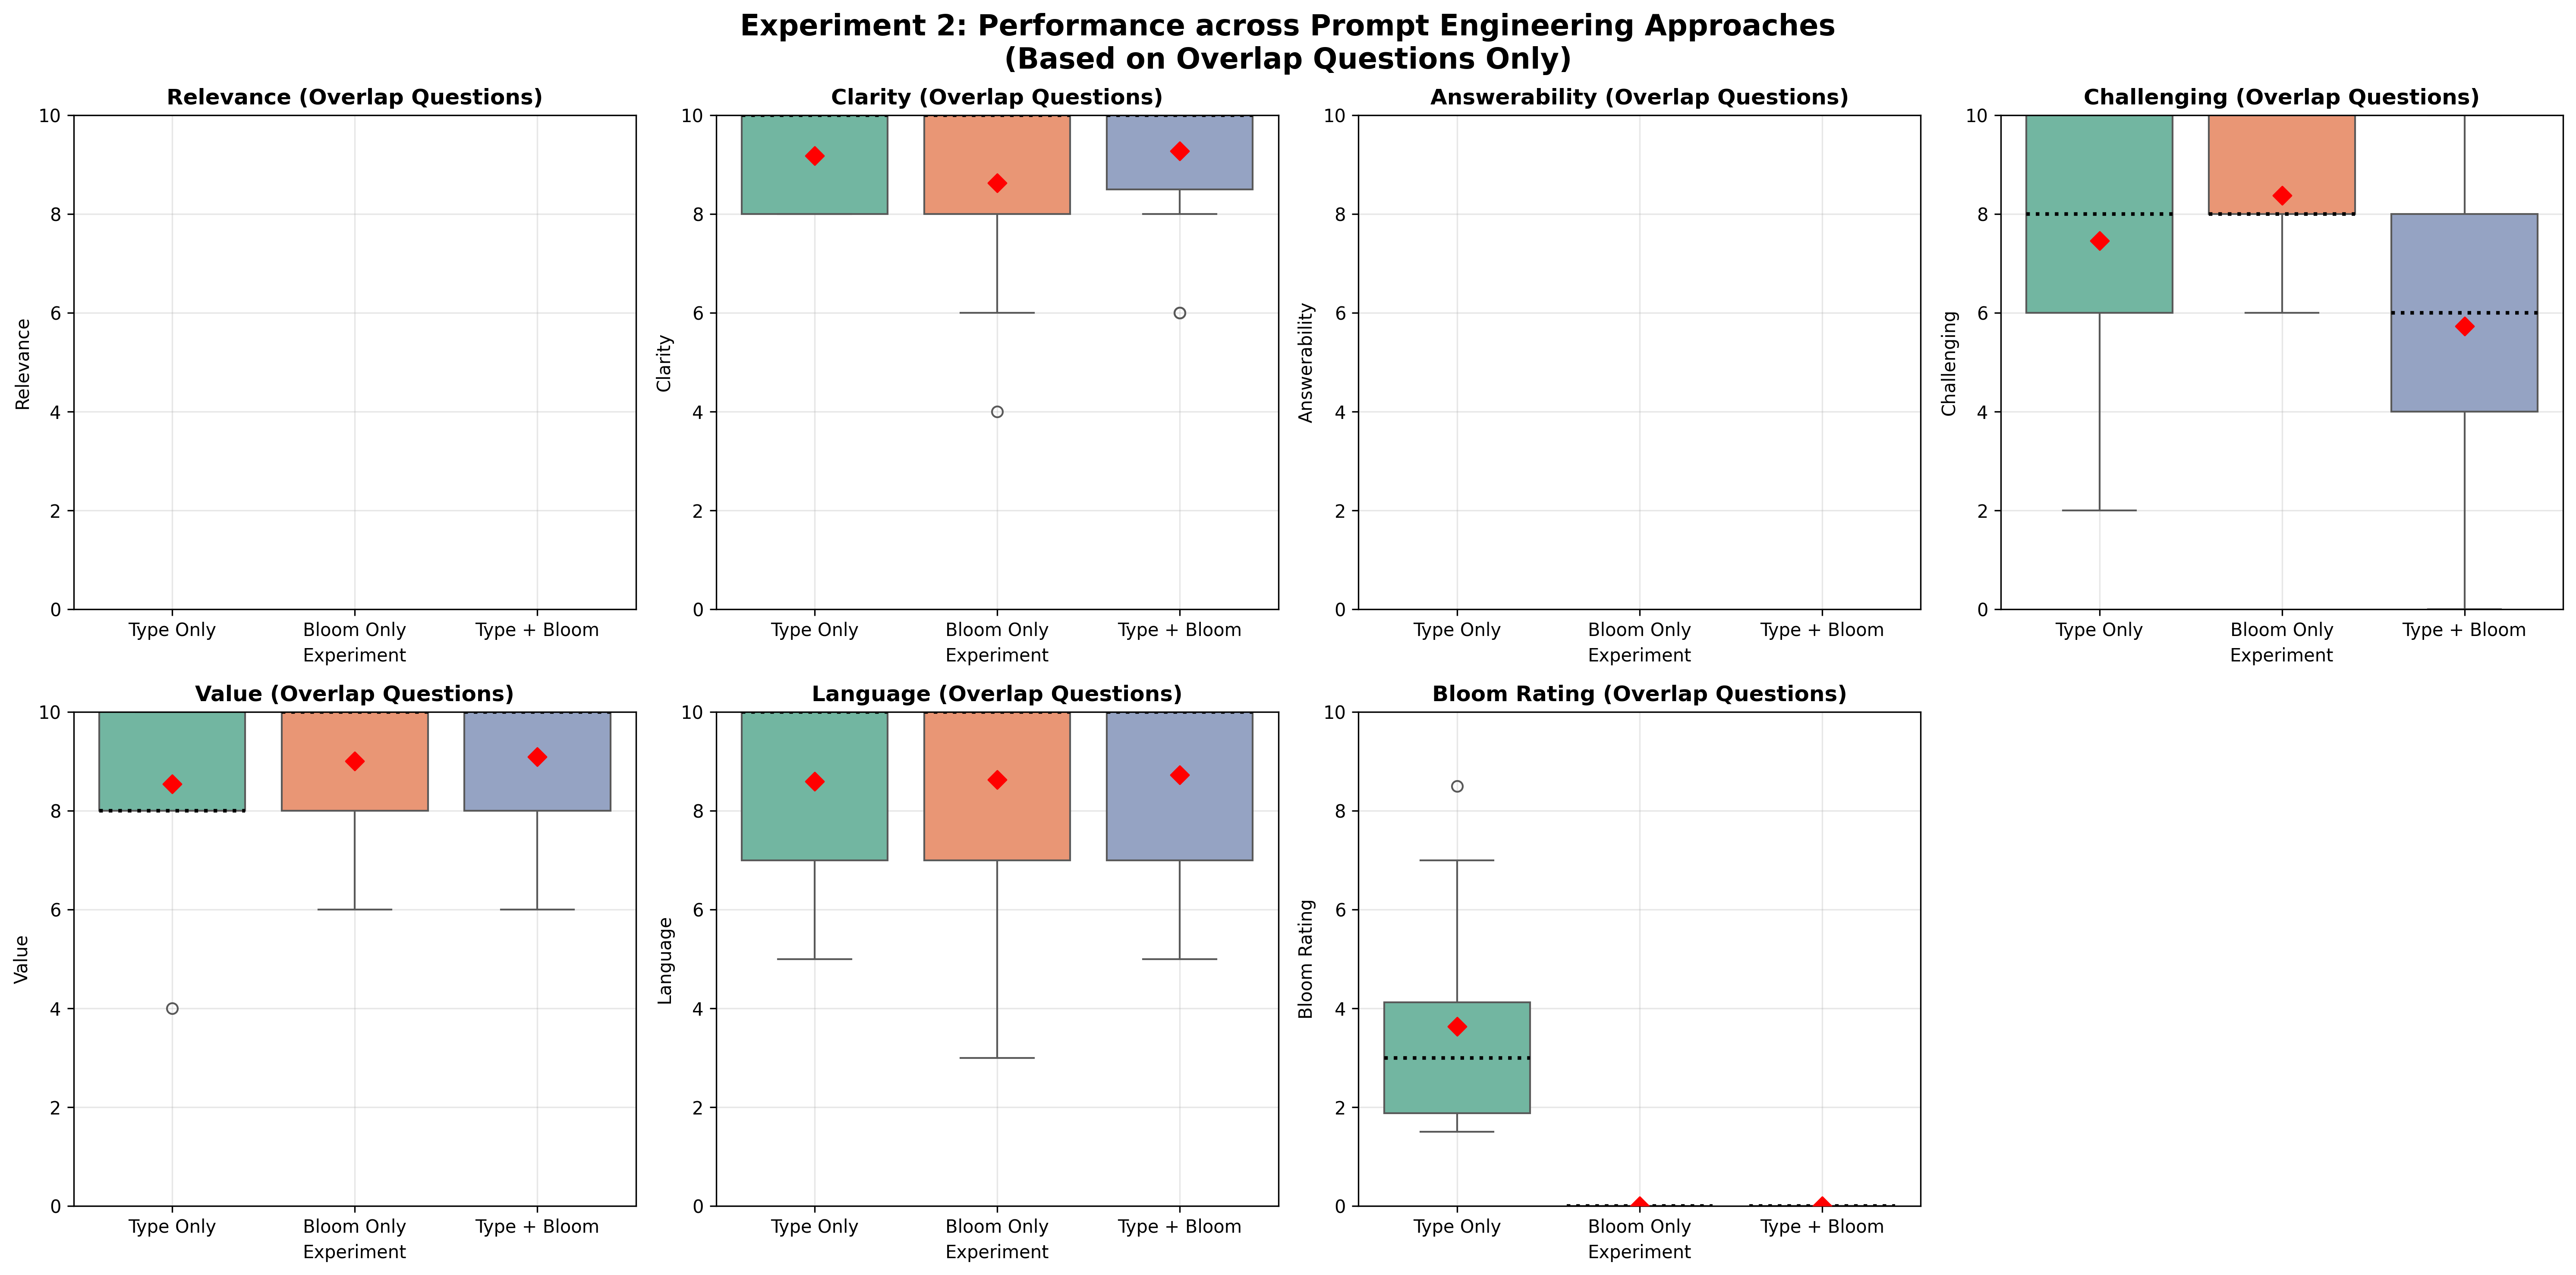

Visualization complete.
Note: This visualization includes only the 16 overlap questions.


In [11]:
# Simplified Visualization: Experiment Performance (OVERLAP QUESTIONS ONLY)
print("=== VISUALIZATION: PERFORMANCE BY EXPERIMENT (OVERLAP QUESTIONS ONLY) ===")

if len(df_overlap_only) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        # Use df_overlap_only consistently for all metrics (ONLY overlap questions)
        df_plot = df_overlap_only[[metric, 'experiment']].dropna()
        
        if len(df_plot) > 0:
            metric_display = metric_labels[metric]
            colors = ['#66c2a5', '#fc8d62', '#8da0cb']
            
            sns.boxplot(data=df_plot, x='experiment', y=metric, ax=axes[i], palette=colors,
                        medianprops={'color': 'black', 'linewidth': 2, 'linestyle': ':'})
            
            # Add mean markers
            for j, exp in enumerate(['exp2a', 'exp2b', 'exp2c']):
                exp_data = df_plot[df_plot['experiment'] == exp][metric]
                if len(exp_data) > 0:
                    mean_val = exp_data.mean()
                    axes[i].scatter(j, mean_val, color='red', marker='D', s=50, zorder=3)
            
            axes[i].set_ylim(0, 10)
            axes[i].set_title(f'{metric_display} (Overlap Questions)', fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Experiment')
            axes[i].set_ylabel(metric_display)
            axes[i].grid(True, alpha=0.3)
            
            # Rename x-axis labels
            axes[i].set_xticklabels(['Type Only', 'Bloom Only', 'Type + Bloom'])
        else:
            axes[i].set_title(f'{metric_labels[metric]} - No Overlap Data')
            axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[i].transAxes)

    # Hide empty subplot
    axes[7].set_visible(False)

    plt.suptitle('Experiment 2: Performance across Prompt Engineering Approaches\n(Based on Overlap Questions Only)', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Visualization complete.")
    print(f"Note: This visualization includes only the {len(overlap_info['overlap_questions'])} overlap questions.")
    
else:
    print("No overlap questions available - cannot create visualization.")
    print("Check that overlap_config is correctly implemented and data is loaded.")

# Inter-Student Reliability Analysis

Analysis of agreement between student evaluators on overlapping questions.

In [12]:
# --- FLEISS' KAPPA: NUR SCHNITTMENGE (OVERLAP) ---
print("\n" + "="*60)
print("FLEISS' KAPPA INTER-RATER RELIABILITY ANALYSIS")
print("(NUR SCHNITTMENGE: Fragen, die von mind. 2 Studierenden bewertet wurden)")
print("="*60)

from statsmodels.stats.inter_rater import fleiss_kappa

def kappa_level(k):
    """Interpret Fleiss' Kappa value according to Landis & Koch (1977)"""
    if k < 0.2:
        return "Slight"
    elif k < 0.4:
        return "Fair" 
    elif k < 0.6:
        return "Moderate"
    elif k < 0.8:
        return "Substantial"
    else:
        return "Almost Perfect"

# Bestimme die Schnittmenge: Fragen, die von mind. 2 Studierenden bewertet wurden
question_counts = df_config_ratings.groupby('sample_id')['student'].nunique()
overlap_questions = question_counts[question_counts >= 2].index.tolist()
print(f"Gefundene Overlap-Fragen (mind. 2 Bewertungen): {len(overlap_questions)}")

# Filter für Kappa: nur diese Fragen
kappa_data = df_numeric_config[df_numeric_config['sample_id'].isin(overlap_questions)].copy()

def calculate_fleiss_kappa_overlap(metric):
    ratings_data = []
    for q_id in overlap_questions:
        q_data = kappa_data[kappa_data['sample_id'] == q_id]
        scores = q_data[metric].dropna()
        if len(scores) >= 2:
            valid_scores = [max(1, min(10, int(round(s)))) for s in scores if 0 <= s <= 10]
            while len(valid_scores) < 3:
                valid_scores.append(np.nan)
            ratings_data.append(valid_scores[:3])
    if len(ratings_data) < 2:
        return np.nan, len(ratings_data)
    ratings_matrix = np.array(ratings_data)
    valid_rows = ~np.isnan(ratings_matrix).all(axis=1)
    clean_ratings = ratings_matrix[valid_rows]
    if len(clean_ratings) == 0:
        return np.nan, 0
    fleiss_table = np.zeros((len(clean_ratings), 10))
    for i, row in enumerate(clean_ratings):
        for r in row:
            if not np.isnan(r) and 1 <= r <= 10:
                fleiss_table[i, int(r)-1] += 1
    try:
        kappa = fleiss_kappa(fleiss_table)
        return kappa, len(clean_ratings)
    except Exception as e:
        print(f"Error calculating Kappa for {metric}: {e}")
        return np.nan, len(clean_ratings)

# Berechne Fleiss' Kappa für alle Metriken
if len(overlap_questions) > 0:
    print(f"\nCalculating Fleiss' Kappa for {len(overlap_questions)} overlap questions...")
    print(f"Using {len(kappa_data)} Bewertungen aus Schnittmenge.")
    kappa_results = []
    for metric in metrics:
        metric_display = metric_labels.get(metric, metric)
        kappa, n_questions = calculate_fleiss_kappa_overlap(metric)
        kappa_results.append({
            'Metric': metric_display,
            'Fleiss_Kappa': kappa,
            'Agreement_Level': kappa_level(kappa) if not np.isnan(kappa) else 'No data',
            'N_Questions': n_questions
        })
    kappa_df = pd.DataFrame(kappa_results)
    print("\nFleiss' Kappa Results (nur Schnittmenge):")
    display(kappa_df.round(4))
    valid_kappas = kappa_df.dropna(subset=['Fleiss_Kappa'])
    if len(valid_kappas) > 0:
        avg_kappa = valid_kappas['Fleiss_Kappa'].mean()
        print(f"\nSummary:")
        print(f"Average Fleiss' Kappa: {avg_kappa:.4f} ({kappa_level(avg_kappa)})")
        print(f"Metrics with valid Kappa: {len(valid_kappas)}/{len(kappa_df)}")
    print("\nInterpretation (Landis & Koch, 1977):")
    print("  < 0.20: Slight agreement")
    print("  0.20-0.40: Fair agreement")
    print("  0.40-0.60: Moderate agreement") 
    print("  0.60-0.80: Substantial agreement")
    print("  > 0.80: Almost perfect agreement")
else:
    print("Keine Overlap-Fragen gefunden - kein Fleiss' Kappa möglich.")
    kappa_df = pd.DataFrame()


FLEISS' KAPPA INTER-RATER RELIABILITY ANALYSIS
(NUR SCHNITTMENGE: Fragen, die von mind. 2 Studierenden bewertet wurden)
Gefundene Overlap-Fragen (mind. 2 Bewertungen): 16

Calculating Fleiss' Kappa for 16 overlap questions...
Using 60 Bewertungen aus Schnittmenge.
Error calculating Kappa for clarity: 
Error calculating Kappa for challenging: 
Error calculating Kappa for value: 
Error calculating Kappa for language: 
Error calculating Kappa for bloom_rating: 

Fleiss' Kappa Results (nur Schnittmenge):


,Metric,Fleiss_Kappa,Agreement_Level,N_Questions
0,Relevance,NaN,No data,0
1,Clarity,NaN,No data,16
2,Answerability,NaN,No data,0
3,Challenging,NaN,No data,16
4,Value,NaN,No data,16
5,Language,NaN,No data,16
6,Bloom Rating,NaN,No data,16



Interpretation (Landis & Koch, 1977):
  < 0.20: Slight agreement
  0.20-0.40: Fair agreement
  0.40-0.60: Moderate agreement
  0.60-0.80: Substantial agreement
  > 0.80: Almost perfect agreement


In [13]:
def save_results():
    """Save key results from the analysis (OVERLAP QUESTIONS ONLY)."""
    
    print("Saving key results (based on overlap questions only)...")
    
    # Save basic statistics (overlap questions only)
    if 'overall_stats' in locals() and not overall_stats.empty:
        overall_stats.to_csv(os.path.join(output_tables_path, "exp2_overall_statistics_overlap_only.csv"))
        print("Saved overall statistics (overlap questions only)")
    
    if 'exp_stats' in locals() and not exp_stats.empty:
        exp_stats.to_csv(os.path.join(output_tables_path, "exp2_experiment_statistics_overlap_only.csv"))
        print("Saved experiment statistics (overlap questions only)")
    
    # # Save reliability results
    # if 'reliability' in locals() and reliability:
    #     reliability_df = pd.DataFrame.from_dict(reliability, orient='index')
    #     reliability_df.to_csv(os.path.join(output_tables_path, "exp2_reliability_analysis_overlap_only.csv"))
    #     print("Saved reliability analysis (overlap questions only)")
    
    # Save Fleiss' Kappa results
    if 'kappa_df' in locals() and not kappa_df.empty:
        kappa_df.to_csv(os.path.join(output_tables_path, "exp2_fleiss_kappa_overlap_only.csv"), index=False)
        print("Saved Fleiss' Kappa results (overlap questions only)")
    
    # # Save overlap summary
    # overlap_summary = {
    #     'total_overlap_questions': len(overlap_info['overlap_questions']),
    #     'overlap_questions': overlap_info['overlap_questions'],
    #     'expected_overlaps': overlap_info['expected_overlaps'],
    #     'found_overlaps': overlap_info['found_overlaps']
    # }
    
    # with open(os.path.join(output_tables_path, "exp2_overlap_summary.json"), 'w') as f:
    #     import json
    #     json.dump(overlap_summary, f, indent=2, default=str)
    # print("Saved overlap summary")
    
    # # Save dataset info
    # dataset_info = {
    #     'total_evaluations_loaded': len(df_combined),
    #     'overlap_evaluations_analyzed': len(df_overlap_only) if 'df_overlap_only' in locals() else 0,
    #     'overlap_questions': len(overlap_info['overlap_questions']),
    #     'analysis_scope': 'overlap_questions_only',
    #     'note': 'All statistics and analyses are based ONLY on the overlap questions defined in overlap_config'
    # }
    
    # with open(os.path.join(output_tables_path, "exp2_dataset_info.json"), 'w') as f:
    #     import json
    #     json.dump(dataset_info, f, indent=2, default=str)
    # print("Saved dataset information")
    
    print(f"\nResults saved to: {output_tables_path}")

# Execute save
save_results()

print(f"\n" + "="*60)
print("ANALYSIS COMPLETE - OVERLAP QUESTIONS ONLY")
print("="*60)
print(f"Data loaded: {len(df_combined)} total evaluations")
print(f"Analyzed: {len(df_overlap_only) if 'df_overlap_only' in locals() else 0} overlap evaluations")
print(f"Overlap questions identified: {len(overlap_info['overlap_questions'])}")
print(f"Metrics analyzed: {len(metrics)}")
print(f"Students: {sorted(df_combined['student'].unique())}")
print(f"Experiments: {sorted(df_combined['experiment'].unique())}")

# Show overlap summary
print(f"\nOverlap Configuration Summary:")
for student_key, student_config in overlap_config.items():
    student_num = student_key.split('_')[1]
    print(f"Student {student_num}:")
    for exp, questions in student_config.items():
        if questions:
            print(f"  {exp}: Questions {list(questions)}")
        else:
            print(f"  {exp}: No questions assigned")

if len(overlap_info['overlap_questions']) > 0:
    print(f"\nInter-rater reliability analysis completed (overlap questions only)")
    if 'kappa_df' in locals() and not kappa_df.empty:
        valid_kappas = kappa_df.dropna(subset=['Fleiss_Kappa'])
        if len(valid_kappas) > 0:
            avg_kappa = valid_kappas['Fleiss_Kappa'].mean()
            print(f"Average Fleiss' Kappa: {avg_kappa:.3f}")
    
    print(f"\nIMPORTANT: All analyses (statistics, visualizations, reliability) ")
    print(f"   are based ONLY on the {len(overlap_info['overlap_questions'])} overlap questions.")
    print(f"   This ensures consistent inter-rater reliability analysis.")
else:
    print(f"No overlap questions found - check data and overlap_config")

Saving key results (based on overlap questions only)...

Results saved to: /home/malde/git/bachelor-thesis/40_evaluation/exp2/qualitative/tables

ANALYSIS COMPLETE - OVERLAP QUESTIONS ONLY
Data loaded: 100 total evaluations
Analyzed: 60 overlap evaluations
Overlap questions identified: 16
Metrics analyzed: 7
Students: [np.int64(1), np.int64(2), np.int64(3)]
Experiments: ['exp2a', 'exp2b', 'exp2c']

Overlap Configuration Summary:
Student 1:
  exp2a: Questions [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
  exp2b: Questions [1, 2, 3, 4]
  exp2c: No questions assigned
Student 2:
  exp2a: Questions [11, 12, 13, 14, 15, 16]
  exp2b: Questions [1, 2, 3, 4, 5, 6, 7, 8]
  exp2c: Questions [1, 2, 3, 4, 5, 6]
Student 3:
  exp2a: No questions assigned
  exp2b: Questions [5, 6, 7, 8]
  exp2c: Questions [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

Inter-rater reliability analysis completed (overlap questions only)

IMPORTANT: All analyses (statistics, visualizations, reliabili

In [14]:
# --- FLEISS' KAPPA ANALYSE (NUR OVERLAP-FRAGEN) ---
print("\n" + "="*60)
print("FLEISS' KAPPA INTER-RATER RELIABILITY ANALYSIS")
print("(NUR OVERLAP-FRAGEN, wie in overlap_config definiert)")
print("="*60)

from statsmodels.stats.inter_rater import fleiss_kappa

def kappa_level(k):
    if k < 0.2:
        return "Slight"
    elif k < 0.4:
        return "Fair"
    elif k < 0.6:
        return "Moderate"
    elif k < 0.8:
        return "Substantial"
    else:
        return "Almost Perfect"

def ratings_to_fleiss_table(ratings, n_categories=10):
    table = np.zeros((len(ratings), n_categories), dtype=int)
    for i, row in enumerate(ratings):
        for r in row:
            if not np.isnan(r) and 1 <= int(r) <= n_categories:
                table[i, int(r)-1] += 1
    return table

def calculate_fleiss_for_overlap(metric):
    ratings = []
    for qid in overlap_info['overlap_questions']:
        qdata = df_overlap_only[df_overlap_only['sample_id'] == qid]
        vals = qdata[metric].dropna().tolist()
        # Scale values to 0-10, round, map to 1-10
        vals = [max(1, min(10, int(round(v)))) for v in vals if pd.notnull(v) and 0 <= v <= 10]
        # Padding to 3 evaluators (if less)
        while len(vals) < 3:
            vals.append(np.nan)
        ratings.append(vals[:3])
    # Remove questions without valid ratings
    ratings = [row for row in ratings if any([not np.isnan(x) for x in row])]
    if len(ratings) < 2:
        return np.nan, 0
    table = ratings_to_fleiss_table(ratings)
    try:
        kappa = fleiss_kappa(table)
        return kappa, len(ratings)
    except Exception as e:
        print(f"Fehler bei Fleiss' Kappa für {metric}: {e}")
        return np.nan, len(ratings)

if len(overlap_info['overlap_questions']) > 0 and len(df_overlap_only) > 0:
    kappa_results = []
    for metric in metrics:
        label = metric_labels.get(metric, metric)
        kappa, n = calculate_fleiss_for_overlap(metric)
        kappa_results.append({
            'Metrik': label,
            'Fleiss_Kappa': kappa,
            'Agreement_Level': kappa_level(kappa) if not np.isnan(kappa) else 'No data',
            'N_Questions': n
        })
    kappa_df = pd.DataFrame(kappa_results)
    print("\nFleiiss' Kappa results (only overlap questions):")
    display(kappa_df.round(4))
    valid_kappas = kappa_df.dropna(subset=['Fleiss_Kappa'])
    if len(valid_kappas) > 0:
        avg_kappa = valid_kappas['Fleiss_Kappa'].mean()
        print(f"\nAverage Fleiss' Kappa: {avg_kappa:.4f} ({kappa_level(avg_kappa)})")
else:
    print("No overlap questions found or no data for fleaus' Kappa.")


FLEISS' KAPPA INTER-RATER RELIABILITY ANALYSIS
(NUR OVERLAP-FRAGEN, wie in overlap_config definiert)
Fehler bei Fleiss' Kappa für clarity: 
Fehler bei Fleiss' Kappa für challenging: 
Fehler bei Fleiss' Kappa für value: 
Fehler bei Fleiss' Kappa für language: 
Fehler bei Fleiss' Kappa für bloom_rating: 

Fleiiss' Kappa results (only overlap questions):


,Metrik,Fleiss_Kappa,Agreement_Level,N_Questions
0,Relevance,NaN,No data,0
1,Clarity,NaN,No data,16
2,Answerability,NaN,No data,0
3,Challenging,NaN,No data,16
4,Value,NaN,No data,16
5,Language,NaN,No data,16
6,Bloom Rating,NaN,No data,16
